In [1]:
import os
import random
import json
from collections import Counter

DATASET_PATH = "/kaggle/input/datasets/qianlanzz/xbd-dataset/xbd"

# -------------------------------
# 1. Basic structure
# -------------------------------
for root, dirs, files in os.walk(DATASET_PATH):
    print(f"\n📁 {root}")
    print(f"   Subfolders: {dirs[:5]}")
    print(f"   Files: {files[:5]}")
    break


# -------------------------------
# 2. Collect files
# -------------------------------
image_files = []
json_files = []

for root, dirs, files in os.walk(DATASET_PATH):
    for file in files:
        full_path = os.path.join(root, file)
        
        if file.endswith(".png"):
            image_files.append(full_path)
        elif file.endswith(".json"):
            json_files.append(full_path)

print(f"\n🖼️ Total images: {len(image_files)}")
print(f"📄 Total jsons: {len(json_files)}")


# -------------------------------
# 3. Pick sample image
# -------------------------------
sample_img = random.choice(image_files)
print("\nSample image:", sample_img)


# -------------------------------
# 4. Find matching JSON (SAFE)
# -------------------------------
def find_json(img_path, json_list):
    base_name = os.path.basename(img_path).replace(".png", "")
    
    for j in json_list:
        if base_name in j:
            return j
    return None

sample_json = find_json(sample_img, json_files)

print("Matched JSON:", sample_json)


# -------------------------------
# 5. Load JSON safely
# -------------------------------
if sample_json is not None:
    with open(sample_json) as f:
        data = json.load(f)
    
    features = data.get("features", {})
    buildings = features.get("xy", [])
    
    print(f"\n🏠 Buildings in sample: {len(buildings)}")
    
    if len(buildings) > 0:
        print("\nSample building:")
        print(buildings[0])
else:
    print("\n⚠️ No matching JSON found (this can happen for some images)")


# -------------------------------
# 6. Damage distribution (quick check)
# -------------------------------
damage_counts = Counter()

for json_file in json_files[:200]:  # small sample
    with open(json_file) as f:
        data = json.load(f)

    buildings = data.get("features", {}).get("xy", [])

    for b in buildings:
        damage = b.get("properties", {}).get("subtype", "unknown")
        damage_counts[damage] += 1

print("\n📊 Damage distribution (sample):")
print(damage_counts)


# -------------------------------
# 7. Pre vs Post split
# -------------------------------
pre_images = [p for p in image_files if "pre_disaster" in p]
post_images = [p for p in image_files if "post_disaster" in p]

print(f"\nPre images: {len(pre_images)}")
print(f"Post images: {len(post_images)}")


# -------------------------------
# 8. Pair check
# -------------------------------
def get_pair(pre_path):
    return pre_path.replace("pre_disaster", "post_disaster")

sample_pre = random.choice(pre_images)
sample_post = get_pair(sample_pre)

print("\nPAIR CHECK:")
print("PRE :", sample_pre)
print("POST:", sample_post)
print("Exists:", os.path.exists(sample_post))


📁 /kaggle/input/datasets/qianlanzz/xbd-dataset/xbd
   Subfolders: ['tier1', 'tier3', 'test', 'hold', 'train']
   Files: []

🖼️ Total images: 55180
📄 Total jsons: 22068

Sample image: /kaggle/input/datasets/qianlanzz/xbd-dataset/xbd/tier1/masks/hurricane-michael_00000156_post_disaster_rgb.png
Matched JSON: None

⚠️ No matching JSON found (this can happen for some images)

📊 Damage distribution (sample):
Counter({'unknown': 5183, 'no-damage': 3613, 'destroyed': 2067, 'minor-damage': 1119, 'major-damage': 888, 'un-classified': 80})

Pre images: 22073
Post images: 33107

PAIR CHECK:
PRE : /kaggle/input/datasets/qianlanzz/xbd-dataset/xbd/tier3/masks/woolsey-fire_00000723_pre_disaster.png
POST: /kaggle/input/datasets/qianlanzz/xbd-dataset/xbd/tier3/masks/woolsey-fire_00000723_post_disaster.png
Exists: True


In [2]:
import os

DATASET_PATH = "/kaggle/input/datasets/qianlanzz/xbd-dataset/xbd"

for tier in ["tier1", "tier3"]:
    print(f"\n📂 {tier}")
    
    tier_path = os.path.join(DATASET_PATH, tier)
    
    for sub in os.listdir(tier_path):
        print("  └──", sub)


📂 tier1
  └── labels
  └── images
  └── masks

📂 tier3
  └── labels
  └── images
  └── masks


In [3]:
def count_images(path):
    count = 0
    for root, _, files in os.walk(path):
        for f in files:
            if f.endswith(".png"):
                count += 1
    return count

for tier in ["tier1", "tier3"]:
    path = os.path.join(DATASET_PATH, tier)
    print(f"{tier}: {count_images(path)} images")

tier1: 13995 images
tier3: 31845 images


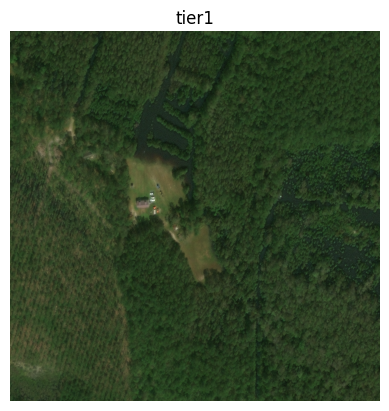

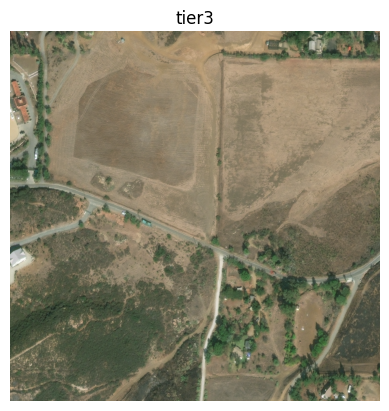

In [4]:
import random
import cv2
import matplotlib.pyplot as plt

def get_random_image(tier):
    tier_path = os.path.join(DATASET_PATH, tier, "images")  # FIX
    
    imgs = []
    
    for root, _, files in os.walk(tier_path):
        for f in files:
            if f.endswith(".png") and "post_disaster" in f:
                imgs.append(os.path.join(root, f))
    
    return random.choice(imgs)

for tier in ["tier1", "tier3"]:
    img_path = get_random_image(tier)
    
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    plt.imshow(img)
    plt.title(tier)
    plt.axis("off")
    plt.show()

IMG: /kaggle/input/datasets/qianlanzz/xbd-dataset/xbd/tier3/images/pinery-bushfire_00000522_post_disaster.png
JSON: /kaggle/input/datasets/qianlanzz/xbd-dataset/xbd/tier3/labels/pinery-bushfire_00000522_post_disaster.json


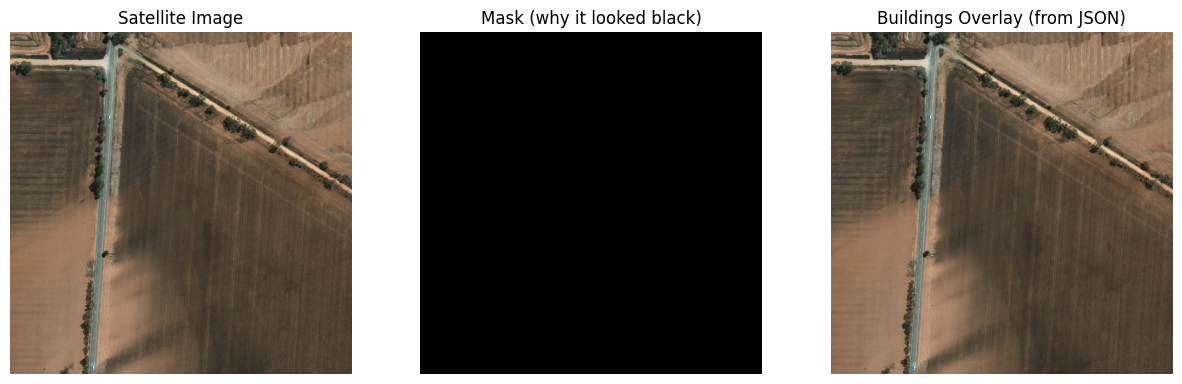

In [5]:
def get_json_from_image(img_path):
    base = os.path.basename(img_path).replace(".png", "")
    
    label_dir = img_path.replace("images", "labels")
    label_dir = os.path.dirname(label_dir)
    
    for f in os.listdir(label_dir):
        if base in f and f.endswith(".json"):
            return os.path.join(label_dir, f)
    
    return None

img_path = get_random_image("tier3")
print("IMG:", img_path)

json_path = get_json_from_image(img_path)
print("JSON:", json_path)

import cv2
import matplotlib.pyplot as plt
import numpy as np
import os
import json

# -------------------------------
# 1. Get matching mask path
# -------------------------------
def get_mask_from_image(img_path):
    return img_path.replace("images", "masks")

# -------------------------------
# 2. Draw polygons from JSON
# -------------------------------
def draw_buildings(img, json_path):
    if json_path is None:
        return img
    
    with open(json_path) as f:
        data = json.load(f)

    buildings = data.get("features", {}).get("xy", [])

    for b in buildings:
        wkt = b.get("wkt", "")
        
        if "POLYGON" in wkt:
            coords = wkt.replace("POLYGON ((", "").replace("))", "")
            points = []
            
            for pair in coords.split(","):
                x, y = map(float, pair.strip().split())
                points.append([int(x), int(y)])
            
            pts = np.array(points, np.int32)
            cv2.polylines(img, [pts], True, (0,255,0), 2)

    return img

# -------------------------------
# 3. Load image, mask, overlay
# -------------------------------
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

mask_path = get_mask_from_image(img_path)
mask = cv2.imread(mask_path, 0) if os.path.exists(mask_path) else None

overlay = draw_buildings(img.copy(), json_path)

# -------------------------------
# 4. Plot all
# -------------------------------
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(img)
plt.title("Satellite Image")
plt.axis("off")

plt.subplot(1,3,2)
if mask is not None:
    plt.imshow(mask, cmap='gray')
    plt.title("Mask (why it looked black)")
else:
    plt.title("No Mask Found")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(overlay)
plt.title("Buildings Overlay (from JSON)")
plt.axis("off")

plt.show()

In [6]:
def wkt_to_bbox(wkt):
    try:
        coords = wkt.replace("POLYGON ((", "").replace("))", "")
        
        points = []
        for pair in coords.split(","):
            x, y = map(float, pair.strip().split())
            points.append((x, y))
        
        xs = [p[0] for p in points]
        ys = [p[1] for p in points]
        
        xmin, xmax = min(xs), max(xs)
        ymin, ymax = min(ys), max(ys)
        
        return xmin, ymin, xmax, ymax
    
    except:
        return None

In [7]:
CLASS_MAP = {
    "no-damage": 0,
    "minor-damage": 1,
    "major-damage": 2,
    "destroyed": 3
}

In [8]:
import json

def parse_json(json_path):
    boxes = []
    labels = []
    
    with open(json_path) as f:
        data = json.load(f)
    
    buildings = data.get("features", {}).get("xy", [])
    
    for b in buildings:
        props = b.get("properties", {})
        damage = props.get("subtype", None)
        
        # Skip unwanted labels
        if damage not in CLASS_MAP:
            continue
        
        bbox = wkt_to_bbox(b.get("wkt", ""))
        
        if bbox is None:
            continue
        
        boxes.append(bbox)
        labels.append(CLASS_MAP[damage])
    
    return boxes, labels

In [9]:
boxes, labels = parse_json(json_path)

print("Total objects:", len(boxes))

if len(boxes) > 0:
    print("Sample bbox:", boxes[0])
    print("Sample label:", labels[0])

Total objects: 0


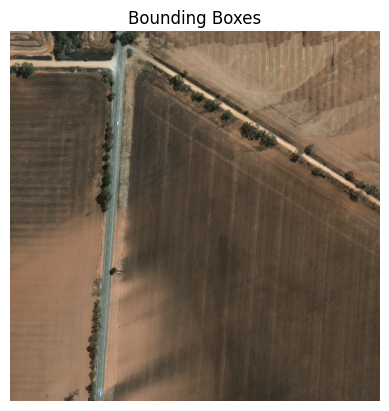

In [10]:
import cv2
import matplotlib.pyplot as plt

def draw_bboxes(img_path, boxes, labels):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    for (xmin, ymin, xmax, ymax), label in zip(boxes, labels):
        
        # Color by damage class
        if label == 0:
            color = (0,255,0)      # green
        elif label == 1:
            color = (255,255,0)    # yellow
        elif label == 2:
            color = (255,165,0)    # orange
        else:
            color = (255,0,0)      # red
        
        cv2.rectangle(img, (int(xmin), int(ymin)), (int(xmax), int(ymax)), color, 2)
    
    plt.imshow(img)
    plt.title("Bounding Boxes")
    plt.axis("off")
    plt.show()


draw_bboxes(img_path, boxes, labels)

yolo dataset creation

In [11]:
def convert_to_yolo(bbox, img_w, img_h):
    xmin, ymin, xmax, ymax = bbox
    
    x_center = (xmin + xmax) / 2.0
    y_center = (ymin + ymax) / 2.0
    
    width = xmax - xmin
    height = ymax - ymin
    
    # Normalize
    x_center /= img_w
    y_center /= img_h
    width /= img_w
    height /= img_h
    
    return x_center, y_center, width, height


import os

OUTPUT_PATH = "/kaggle/working/yolo_dataset"

os.makedirs(f"{OUTPUT_PATH}/images", exist_ok=True)
os.makedirs(f"{OUTPUT_PATH}/labels", exist_ok=True)



In [12]:
import shutil
import cv2

def process_image(img_path):
    json_path = get_json_from_image(img_path)
    
    if json_path is None:
        return
    
    boxes, labels = parse_json(json_path)
    
    if len(boxes) == 0:
        return
    
    img = cv2.imread(img_path)
    h, w = img.shape[:2]
    
    # Save image
    filename = os.path.basename(img_path)
    new_img_path = os.path.join(OUTPUT_PATH, "images", filename)
    shutil.copy(img_path, new_img_path)
    
    # Create label file
    label_path = os.path.join(OUTPUT_PATH, "labels", filename.replace(".png", ".txt"))
    
    with open(label_path, "w") as f:
        for bbox, label in zip(boxes, labels):
            x, y, bw, bh = convert_to_yolo(bbox, w, h)
            f.write(f"{label} {x} {y} {bw} {bh}\n")

In [13]:
def get_disaster_type(img_path):
    filename = os.path.basename(img_path)
    
    # Example: pinery-bushfire_00001722_post_disaster.png
    disaster = filename.split("_")[0]
    
    return disaster

from collections import defaultdict

grouped = defaultdict(list)

for tier in ["tier1", "tier3"]:
    img_dir = os.path.join(DATASET_PATH, tier, "images")
    
    for root, _, files in os.walk(img_dir):
        for f in files:
            if not (f.endswith(".png") and "post_disaster" in f):
                continue
            
            img_path = os.path.join(root, f)
            json_path = get_json_from_image(img_path)
            
            if json_path is None:
                continue
            
            boxes, labels = parse_json(json_path)
            
            if len(labels) == 0:
                continue
            
            disaster = get_disaster_type(img_path)
            unique_labels = set(labels)
            
            for lbl in unique_labels:
                key = (disaster, lbl)
                grouped[key].append(img_path)

for key, imgs in grouped.items():
    print(f"{key}: {len(imgs)}")

TARGET_PER_GROUP = 100  # adjust

selected_images = set()

for key, imgs in grouped.items():
    if len(imgs) <= TARGET_PER_GROUP:
        sampled = imgs
    else:
        sampled = random.sample(imgs, TARGET_PER_GROUP)
    
    selected_images.update(sampled)

selected_images = list(selected_images)

print("Total selected images:", len(selected_images))

for img_path in selected_images:
    process_image(img_path)

print("Diverse + balanced dataset created!")

('hurricane-harvey', 2): 186
('hurricane-harvey', 3): 75
('hurricane-florence', 0): 193
('palu-tsunami', 0): 106
('hurricane-matthew', 1): 176
('hurricane-matthew', 3): 167
('mexico-earthquake', 0): 120
('palu-tsunami', 2): 62
('palu-tsunami', 3): 78
('hurricane-michael', 0): 324
('hurricane-michael', 1): 314
('hurricane-michael', 2): 260
('hurricane-harvey', 0): 155
('hurricane-florence', 1): 57
('midwest-flooding', 0): 220
('hurricane-matthew', 0): 104
('hurricane-matthew', 2): 153
('santa-rosa-wildfire', 0): 173
('santa-rosa-wildfire', 3): 160
('hurricane-michael', 3): 181
('hurricane-florence', 2): 136
('midwest-flooding', 3): 34
('midwest-flooding', 1): 75
('midwest-flooding', 2): 43
('socal-fire', 0): 325
('santa-rosa-wildfire', 1): 39
('socal-fire', 3): 182
('mexico-earthquake', 1): 25
('mexico-earthquake', 2): 9
('hurricane-harvey', 1): 128
('hurricane-florence', 3): 14
('santa-rosa-wildfire', 2): 35
('socal-fire', 1): 34
('mexico-earthquake', 3): 2
('socal-fire', 2): 34
('guat

In [14]:
print("Images:", len(os.listdir(f"{OUTPUT_PATH}/images")))
print("Labels:", len(os.listdir(f"{OUTPUT_PATH}/labels")))

Images: 3443
Labels: 3443


In [15]:
yaml_content = """
train: /kaggle/working/yolo_dataset/images
val: /kaggle/working/yolo_dataset/images

nc: 4
names: ['no-damage', 'minor-damage', 'major-damage', 'destroyed']
"""

with open("/kaggle/working/data.yaml", "w") as f:
    f.write(yaml_content)

In [16]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 30.7 MB/s eta 0:00:0000:01


In [17]:
from ultralytics import YOLO
model = YOLO("yolo11s.pt")

model.train(
    data="/kaggle/working/data.yaml",
    epochs=30,
    imgsz=800,
    batch=8,        # safe split → 4 per GPU
    workers=2,
    device=[0,1]    # multi-GPU
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.33 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
                                                       CUDA:1 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=0,1, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1

Ultralytics 8.4.33 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,414,348 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4844.9±1150.9 MB/s, size: 1516.1 KB)
val: Scanning /kaggle/working/yolo_dataset/labels.cache... 3443 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3443/3443 601.7Mit/s 0.0s
train: /kaggle/working/yolo_dataset/images/palu-tsunami_00000106_post_disaster.png: 1 duplicate labels removed
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 216/216 2.2it/s 1:38<0.4ss
                   all       3443     232805      0.546      0.367      0.374      0.185
             no-damage       2817     169130      0.612      0.467        0.5      0.269
          minor-damage       1553      22988      0.458      0.339      0.332      0.173
          major-damage       1517      19059       0.58      0.408       0.41      0.195
  

<Axes: >

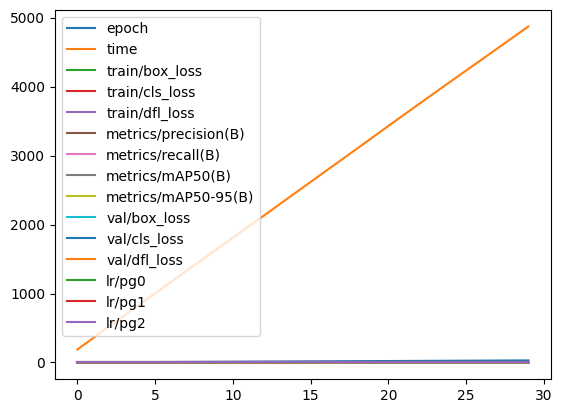

In [18]:
metrics = model.val(data="/kaggle/working/data.yaml")

print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)

print(metrics.box.maps)

metrics.confusion_matrix.plot()

import pandas as pd

results_df = pd.read_csv("/kaggle/working/runs/detect/train/results.csv")
results_df.plot()

In [19]:
import torch

print(torch.cuda.device_count())
print(torch.cuda.get_device_name(0))

2
Tesla T4
